<a href="https://colab.research.google.com/github/beabritw/datasus-dengue-social/blob/feature%2Fmining/mineracao_clusterizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Data Major — Etapa 04: Mineração (Clusterização)
**Responsável:** Mineração / Clusterização

Agrupamento de pacientes de dengue (SINAN) por perfil clínico, demográfico e social usando **Bisecting K-means**, validando depois a taxa de hospitalização de cada grupo.

Pergunta central: *existem grupos naturais de pacientes que compartilham perfis semelhantes — e esses grupos têm taxas de hospitalização diferentes?*

> **Como usar:** rode as células **de cima para baixo**, uma por uma (`Shift+Enter`). Pare no Passo 5, olhe o gráfico do cotovelo, ajuste o `K_FINAL` e continue.

## Pré-requisito
A pasta `Topicos_BD` (Drive da Beatriz) precisa estar adicionada como **atalho** no seu *Meu Drive*. Caso contrário o caminho abaixo não será encontrado.

## Passo 0 — Instalar o PySpark


In [1]:
!pip install -q pyspark

## Passo 1 — Imports, Drive e sessão Spark

In [2]:
from google.colab import drive
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import pandas as pd

drive.mount('/content/drive')

spark = (SparkSession.builder
         .appName('DataMajor_Mining')
         .config('spark.driver.memory', '8g')
         .getOrCreate())

base_path   = '/content/drive/MyDrive/Topicos_BD'
input_path  = os.path.join(base_path, 'processed', 'sinan_dengue_processed')
output_path = os.path.join(base_path, 'processed', 'sinan_dengue_clustered')

Mounted at /content/drive


## Configurações
Valores fixos usados nos passos seguintes. `SEED` garante que o resultado seja sempre o mesmo (reprodutível).

In [3]:
SEED = 42
FRAC_ELBOW = 0.15      # 15% amostral para o cotovelo (~1M registros) — rápido e estável
K_RANGE = range(2, 11) # testa k de 2 a 10

## Passo 2 — Ler o parquet processado
Lê a saída do Transform. Esperado: **6.888.349 registros · 31 colunas · todas int**.

In [4]:
df = spark.read.parquet(input_path)
print(f'Registros: {df.count():,} | Colunas: {len(df.columns)}')
df.printSchema()

Registros: 6,889,831 | Colunas: 31
root
 |-- hospitaliz: integer (nullable = true)
 |-- febre: integer (nullable = true)
 |-- mialgia: integer (nullable = true)
 |-- cefaleia: integer (nullable = true)
 |-- vomito: integer (nullable = true)
 |-- nausea: integer (nullable = true)
 |-- dor_retro: integer (nullable = true)
 |-- dor_costas: integer (nullable = true)
 |-- exantema: integer (nullable = true)
 |-- leucopenia: integer (nullable = true)
 |-- diabetes: integer (nullable = true)
 |-- hipertensa: integer (nullable = true)
 |-- renal: integer (nullable = true)
 |-- hepatopat: integer (nullable = true)
 |-- hematolog: integer (nullable = true)
 |-- idade_anos: double (nullable = true)
 |-- is_regiao_norte: integer (nullable = true)
 |-- is_regiao_nordeste: integer (nullable = true)
 |-- is_regiao_sudeste: integer (nullable = true)
 |-- is_regiao_sul: integer (nullable = true)
 |-- is_mulher: integer (nullable = true)
 |-- is_homem: integer (nullable = true)
 |-- is_raca_branca: inte

## Passo 3 — Separar as features
`hospitaliz` fica **de fora** do modelo. Se entrasse, o algoritmo agruparia os pacientes por ela (0/1), e nós já sabemos quem foi hospitalizado. Ela é mantida no DataFrame para servir de **validação depois** do clustering.

Esperado: **30 features**.

In [5]:
FEATURE_COLS = [c for c in df.columns if c != 'hospitaliz']
print(f'Features para clusterizacao: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Features para clusterizacao: 30
['febre', 'mialgia', 'cefaleia', 'vomito', 'nausea', 'dor_retro', 'dor_costas', 'exantema', 'leucopenia', 'diabetes', 'hipertensa', 'renal', 'hepatopat', 'hematolog', 'idade_anos', 'is_regiao_norte', 'is_regiao_nordeste', 'is_regiao_sudeste', 'is_regiao_sul', 'is_mulher', 'is_homem', 'is_raca_branca', 'is_raca_preta', 'is_raca_amarela', 'is_raca_parda', 'is_raca_indigena', 'is_escol_analfabeto', 'is_escol_fundamental', 'is_escol_medio', 'is_escol_superior']


## Passo 4 — VectorAssembler + StandardScaler
O `VectorAssembler` junta as 30 colunas em um único vetor. O `StandardScaler` normaliza (média 0, desvio 1).

**Por que normalizar é crítico:** `idade_anos` vai de 0 a 120 e as binárias de 0 a 1. Sem normalização, a idade dominaria completamente a distância euclidiana e o algoritmo agruparia só por faixa etária, ignorando o quadro clínico.

In [6]:
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features_raw',
    handleInvalid='skip'
)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)

df_assembled = assembler.transform(df)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled).cache()

print(f'Dataset escalado pronto: {df_scaled.count():,} registros')

Dataset escalado pronto: 6,889,831 registros


## Passo 5 — Método do Cotovelo (escolha do k)
Treina o Bisecting K-means para vários `k` e plota o WSSSE (coesão interna — menor = clusters mais apertados). Procure o **cotovelo**: o ponto onde a curva para de cair forte. Esse é o melhor custo-benefício de `k`.

Rodado em 15% dos dados para ser rápido — a forma da curva é a mesma.

Amostra para elbow: 1,033,801 registros
  k= 2  WSSSE=     25,298,552.59
  k= 3  WSSSE=     24,348,356.49
  k= 4  WSSSE=     23,320,027.03
  k= 5  WSSSE=     22,505,470.46
  k= 6  WSSSE=     21,874,456.23
  k= 7  WSSSE=     21,380,270.50
  k= 8  WSSSE=     20,567,510.59
  k= 9  WSSSE=     20,156,855.37
  k=10  WSSSE=     19,646,263.28


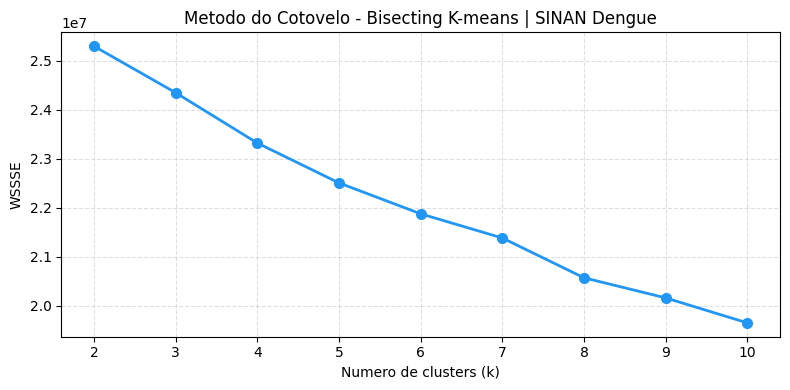

In [7]:
df_elbow = df_scaled.sample(fraction=FRAC_ELBOW, seed=SEED).cache()
print(f'Amostra para elbow: {df_elbow.count():,} registros')

resultados = []
for k in K_RANGE:
    bkm = BisectingKMeans(
        featuresCol='features', predictionCol='cluster',
        k=k, seed=SEED, maxIter=20, minDivisibleClusterSize=20
    )
    modelo = bkm.fit(df_elbow)
    wssse = modelo.summary.trainingCost
    resultados.append((k, wssse))
    print(f'  k={k:2d}  WSSSE={wssse:>18,.2f}')

df_elbow.unpersist()

ks, wssses = zip(*resultados)
plt.figure(figsize=(8, 4))
plt.plot(ks, wssses, 'o-', color='#2196F3', linewidth=2, markersize=7)
plt.xlabel('Numero de clusters (k)')
plt.ylabel('WSSSE')
plt.title('Metodo do Cotovelo - Bisecting K-means | SINAN Dengue')
plt.xticks(list(ks))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/elbow.png', dpi=150)
plt.show()

## Passo 6 — Treinar o modelo final
**Olhe o gráfico acima e ajuste o `K_FINAL`** para o valor do cotovelo. Para dados clínicos de dengue, a literatura costuma encontrar 3 a 5 grupos.

In [12]:
K_FINAL = 4   # confirmado pelo cotovelo

# Treina numa amostra representativa (fit no dataset inteiro é pesado demais p/ o Colab)
df_fit = df_scaled.sample(fraction=0.20, seed=SEED).cache()
print(f'Amostra para treino final: {df_fit.count():,} registros')

bkm_final = BisectingKMeans(
    featuresCol='features', predictionCol='cluster',
    k=K_FINAL, seed=SEED, maxIter=20, minDivisibleClusterSize=20
)
modelo_final = bkm_final.fit(df_fit)

# Aplica o modelo treinado a TODOS os registros (atribuição é leve)
df_clustered = modelo_final.transform(df_scaled)

print(f'WSSSE final (k={K_FINAL}, treino em amostra 20%): {modelo_final.summary.trainingCost:,.2f}')
df_fit.unpersist()

Amostra para treino final: 1,379,386 registros
WSSSE final (k=4, treino em amostra 20%): 31,119,183.24


DataFrame[hospitaliz: int, febre: int, mialgia: int, cefaleia: int, vomito: int, nausea: int, dor_retro: int, dor_costas: int, exantema: int, leucopenia: int, diabetes: int, hipertensa: int, renal: int, hepatopat: int, hematolog: int, idade_anos: double, is_regiao_norte: int, is_regiao_nordeste: int, is_regiao_sudeste: int, is_regiao_sul: int, is_mulher: int, is_homem: int, is_raca_branca: int, is_raca_preta: int, is_raca_amarela: int, is_raca_parda: int, is_raca_indigena: int, is_escol_analfabeto: int, is_escol_fundamental: int, is_escol_medio: int, is_escol_superior: int, features_raw: vector, features: vector]

## Passo 7 — Silhouette Score
Mede o quão **separados** os clusters ficaram (-1 a 1; maior = melhor)

Calculado em 5% amostral por custo.

In [13]:
df_sil = df_clustered.sample(fraction=0.05, seed=SEED)

evaluator = ClusteringEvaluator(
    featuresCol='features', predictionCol='cluster',
    metricName='silhouette', distanceMeasure='squaredEuclidean'
)
sil = evaluator.evaluate(df_sil)
print(f'Silhouette Score (amostra 5%): {sil:.4f}')

Silhouette Score (amostra 5%): 0.0894


## Passo 8 — Análise dos clusters (resultado principal)
Aqui está o coração do projeto. `hospitaliz` entra agora como **validação**, não como entrada do modelo: vemos a taxa de hospitalização de cada grupo formado pelo perfil clínico.

In [14]:
total = df_clustered.count()

print('-- Distribuicao dos clusters --')
(df_clustered.groupBy('cluster')
    .count()
    .withColumn('pct', F.round(col('count') / total * 100, 2))
    .orderBy('cluster').show())

-- Distribuicao dos clusters --
+-------+-------+-----+
|cluster|  count|  pct|
+-------+-------+-----+
|      0|1942596| 28.2|
|      1|2083287|30.24|
|      2|2266040|32.89|
|      3| 597908| 8.68|
+-------+-------+-----+



In [15]:
print('-- Perfil clinico + taxa de hospitalizacao por cluster --')
df_clustered.groupBy('cluster').agg(
    F.count('*').alias('n'),
    F.round(F.mean('hospitaliz') * 100, 2).alias('pct_hospitaliz'),
    F.round(F.mean('idade_anos'), 1).alias('media_idade'),
    F.round(F.mean('febre') * 100, 1).alias('pct_febre'),
    F.round(F.mean('mialgia') * 100, 1).alias('pct_mialgia'),
    F.round(F.mean('cefaleia') * 100, 1).alias('pct_cefaleia'),
    F.round(F.mean('vomito') * 100, 1).alias('pct_vomito'),
    F.round(F.mean('dor_retro') * 100, 1).alias('pct_dor_retro'),
    F.round(F.mean('exantema') * 100, 1).alias('pct_exantema'),
    F.round(F.mean('leucopenia') * 100, 1).alias('pct_leucopenia'),
).orderBy('cluster').show(truncate=False)

-- Perfil clinico + taxa de hospitalizacao por cluster --
+-------+-------+--------------+-----------+---------+-----------+------------+----------+-------------+------------+--------------+
|cluster|n      |pct_hospitaliz|media_idade|pct_febre|pct_mialgia|pct_cefaleia|pct_vomito|pct_dor_retro|pct_exantema|pct_leucopenia|
+-------+-------+--------------+-----------+---------+-----------+------------+----------+-------------+------------+--------------+
|0      |1942596|3.82          |32.4       |80.5     |67.4       |63.1        |16.3      |16.0         |5.9         |2.9           |
|1      |2083287|4.74          |32.4       |89.8     |83.3       |86.1        |29.8      |32.4         |10.8        |3.4           |
|2      |2266040|3.68          |36.6       |88.3     |87.2       |88.1        |30.7      |42.5         |13.8        |6.0           |
|3      |597908 |8.35          |57.7       |83.4     |86.7       |83.9        |31.6      |40.6         |12.4        |8.2           |
+-------+--

In [16]:
print('-- Comorbidades por cluster --')
df_clustered.groupBy('cluster').agg(
    F.count('*').alias('n'),
    F.round(F.mean('diabetes') * 100, 1).alias('pct_diabetes'),
    F.round(F.mean('hipertensa') * 100, 1).alias('pct_hipertensa'),
    F.round(F.mean('renal') * 100, 1).alias('pct_renal'),
    F.round(F.mean('hepatopat') * 100, 1).alias('pct_hepatopat'),
    F.round(F.mean('hematolog') * 100, 1).alias('pct_hematolog'),
).orderBy('cluster').show(truncate=False)

-- Comorbidades por cluster --
+-------+-------+------------+--------------+---------+-------------+-------------+
|cluster|n      |pct_diabetes|pct_hipertensa|pct_renal|pct_hepatopat|pct_hematolog|
+-------+-------+------------+--------------+---------+-------------+-------------+
|0      |1942596|1.3         |3.9           |0.2      |0.2          |0.2          |
|1      |2083287|1.7         |5.4           |0.2      |0.2          |0.3          |
|2      |2266040|0.0         |0.0           |0.0      |0.0          |0.1          |
|3      |597908 |38.9        |83.8          |4.5      |4.4          |4.1          |
+-------+-------+------------+--------------+---------+-------------+-------------+



In [17]:
print('-- Perfil demografico e geografico por cluster --')
df_clustered.groupBy('cluster').agg(
    F.count('*').alias('n'),
    F.round(F.mean('is_mulher') * 100, 1).alias('pct_mulher'),
    F.round(F.mean('is_regiao_norte') * 100, 1).alias('pct_norte'),
    F.round(F.mean('is_regiao_nordeste') * 100, 1).alias('pct_nordeste'),
    F.round(F.mean('is_regiao_sudeste') * 100, 1).alias('pct_sudeste'),
    F.round(F.mean('is_regiao_sul') * 100, 1).alias('pct_sul'),
).orderBy('cluster').show(truncate=False)

-- Perfil demografico e geografico por cluster --
+-------+-------+----------+---------+------------+-----------+-------+
|cluster|n      |pct_mulher|pct_norte|pct_nordeste|pct_sudeste|pct_sul|
+-------+-------+----------+---------+------------+-----------+-------+
|0      |1942596|25.3      |0.3      |1.3         |88.1       |2.5    |
|1      |2083287|62.7      |4.3      |16.8        |53.2       |4.2    |
|2      |2266040|67.6      |0.3      |0.8         |43.0       |49.0   |
|3      |597908 |67.7      |0.5      |1.8         |55.3       |34.1   |
+-------+-------+----------+---------+------------+-----------+-------+



## Passo 9 — Salvar e encerrar
Salva o dataset com a coluna `cluster` (descarta os vetores densos). Esperado: **32 colunas** (31 originais + cluster).

In [18]:
colunas_salvar = [c for c in df.columns] + ['cluster']
df_final = df_clustered.select(*[c for c in colunas_salvar if c in df_clustered.columns])

df_final.write.mode('overwrite').parquet(output_path)
print(f'Dataset clusterizado salvo em: {output_path}')
print(f'Registros: {df_final.count():,} | Colunas: {len(df_final.columns)}')

spark.stop()

Dataset clusterizado salvo em: /content/drive/MyDrive/Topicos_BD/processed/sinan_dengue_clustered
Registros: 6,889,831 | Colunas: 32
